In [28]:
#!/usr/bin/env python3
"""
Radial distribution of JWST star clusters in M82
Catalog: Levy et al. (2023), NIRCam catalog of massive star cluster candidates
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Configuration ────────────────────────────────────────────────────────────

CATALOG_PATH = "./tables/catalog.txt"   # adjust path as needed
HEADER_LINES = 40              # lines to skip before data begins

# M82 center (J2000) — change to e.g. flux-weighted centroid if preferred
RA_CENTER  = 148.9685   # deg
DEC_CENTER =  69.6797   # deg

# Distance to M82 (Freedman et al. 1994; commonly used)
DIST_MPC   = 3.53
PC_PER_ARCSEC = DIST_MPC * 1e6 * np.radians(1/3600)   # ≈ 17.1 pc/arcsec

# Radial binning
N_BINS     = 100      # number of radial bins
RMAX_ARCSEC = 40.0  # max radius to consider [arcsec]; ~2 kpc at M82 distance

# ── Parse catalog ────────────────────────────────────────────────────────────

def parse_catalog(path, skip=HEADER_LINES):
    """Read RA/Dec and flux from the fixed-width catalog."""
    ids, ra, dec, flux = [], [], [], []
    with open(path) as f:
        for i, line in enumerate(f):
            if i < skip:
                continue
            cols = line.split()
            if len(cols) < 3:
                continue
            try:
                ids.append(int(cols[0]))
                ra.append(float(cols[1]))
                dec.append(float(cols[2]))
                flux.append(float(cols[3]))   # F250M flux [mJy]
            except (ValueError, IndexError):
                continue
    return np.array(ids), np.array(ra), np.array(dec), np.array(flux)

# ── Angular separation (small-angle, safe for arcminute scales) ──────────────

def angular_sep_arcsec(ra, dec, ra0=RA_CENTER, dec0=DEC_CENTER):
    """
    Great-circle separation in arcsec using the haversine formula.
    ra, dec, ra0, dec0 all in decimal degrees.
    """
    ra_r  = np.radians(ra);   dec_r  = np.radians(dec)
    ra0_r = np.radians(ra0);  dec0_r = np.radians(dec0)
    dra  = ra_r  - ra0_r
    ddec = dec_r - dec0_r
    a = np.sin(ddec/2)**2 + np.cos(dec_r)*np.cos(dec0_r)*np.sin(dra/2)**2
    sep_rad = 2*np.arcsin(np.sqrt(a))
    return np.degrees(sep_rad) * 3600.0   # → arcsec

Loaded 1356 clusters
Flux-weighted centroid: RA=148.964531 deg, Dec=69.679634 deg
  1356 clusters within 40 arcsec of center
Saved figure → tables/radial_distribution.png


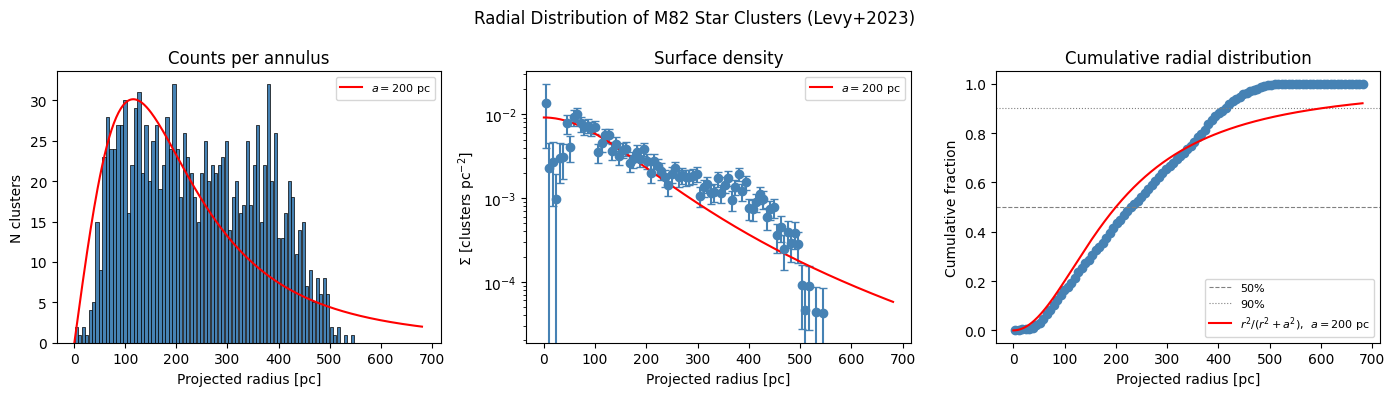


Median projected radius (r50) : 13.8 arcsec  = 236 pc
90th-pct radius   (r90)       : 24.2 arcsec  = 414 pc


In [31]:
ids, ra, dec, flux = parse_catalog(CATALOG_PATH)
print(f"Loaded {len(ids)} clusters")

# Flux-weighted centroid
w = flux / flux.sum()
RA_CENTER  = np.sum(w * ra)
DEC_CENTER = np.sum(w * dec)
print(f"Flux-weighted centroid: RA={RA_CENTER:.6f} deg, Dec={DEC_CENTER:.6f} deg")

r_arcsec = angular_sep_arcsec(ra, dec, ra0=RA_CENTER, dec0=DEC_CENTER)
r_pc     = r_arcsec * PC_PER_ARCSEC

mask = r_arcsec < RMAX_ARCSEC
r    = r_arcsec[mask]
r_p  = r_pc[mask]
print(f"  {mask.sum()} clusters within {RMAX_ARCSEC:.0f} arcsec of center")

# ── Radial bins (linear spacing; swap to np.geomspace for log bins) ──
bin_edges    = np.linspace(0, RMAX_ARCSEC, N_BINS + 1)
bin_centers  = 0.5*(bin_edges[:-1] + bin_edges[1:])
bin_width    = bin_edges[1] - bin_edges[0]   # arcsec

counts, _    = np.histogram(r, bins=bin_edges)

# Projected annular area [arcsec²] → convert to pc² for surface density
arcsec2_per_pc2 = (1.0 / PC_PER_ARCSEC)**2
area_arcsec2 = np.pi * (bin_edges[1:]**2 - bin_edges[:-1]**2)
area_pc2     = area_arcsec2 / arcsec2_per_pc2

sigma        = counts / area_pc2          # clusters per pc²
sigma_err    = np.sqrt(counts) / area_pc2 # Poisson

# ── Cumulative fraction ───────────────────────────────────────────────
cum_frac = np.cumsum(counts) / counts.sum()

# ── Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Radial Distribution of M82 Star Clusters (Levy+2023)", fontsize=12)

r_plot = bin_centers * PC_PER_ARCSEC
bin_width_pc = bin_width * PC_PER_ARCSEC

# 1. Raw counts
ax = axes[0]
ax.bar(r_plot, counts, width=0.9*bin_width_pc, color="steelblue", edgecolor="k", lw=0.5)
ax.set_xlabel("Projected radius [pc]")
ax.set_ylabel("N clusters")
ax.set_title("Counts per annulus")

# 2. Surface density (log scale)
ax = axes[1]
good = counts > 0
ax.errorbar(r_plot[good], sigma[good], yerr=sigma_err[good],
            fmt="o", color="steelblue", capsize=3)
ax.set_yscale("log")
ax.set_xlabel("Projected radius [pc]")
ax.set_ylabel(r"$\Sigma$ [clusters pc$^{-2}$]")
ax.set_title("Surface density")

# 3. Cumulative fraction
ax = axes[2]
ax.plot(r_plot, cum_frac, "o-", color="steelblue")
ax.axhline(0.5, color="gray", ls="--", lw=0.8, label="50%")
ax.axhline(0.9, color="gray", ls=":",  lw=0.8, label="90%")
ax.set_xlabel("Projected radius [pc]")
ax.set_ylabel("Cumulative fraction")
ax.set_title("Cumulative radial distribution")
ax.legend(fontsize=8)

# Plummer
PLUMMER_A_PC = 200.0  # scale radius [pc] for comparison
r_fine = np.linspace(0, r_plot.max(), 300)
ax.plot(r_fine, r_fine**2 / (r_fine**2 + PLUMMER_A_PC**2), "r-", lw=1.5,
        label=f"$r^2/(r^2+a^2)$,  $a={PLUMMER_A_PC:.0f}$ pc")
ax.legend(fontsize=8)
plummer_pdf = 2 * PLUMMER_A_PC**2 * r_fine / (r_fine**2 + PLUMMER_A_PC**2)**2
plummer_pdf *= counts.sum() * bin_width_pc   # normalize to total counts
ax = axes[0]
ax.plot(r_fine, plummer_pdf, "r-", lw=1.5,
        label=f"$a={PLUMMER_A_PC:.0f}$ pc")
ax.legend(fontsize=8)
plummer_sigma = 1.0 / (r_fine**2 + PLUMMER_A_PC**2)**2
# normalize to match data: scale so integral over annuli = total counts
plummer_sigma *= np.sum(sigma[good]) / np.sum(1.0 / (r_plot[good]**2 + PLUMMER_A_PC**2)**2)
ax = axes[1]
ax.plot(r_fine, plummer_sigma, "r-", lw=1.5,
        label=f"$a={PLUMMER_A_PC:.0f}$ pc")
ax.legend(fontsize=8)

plt.tight_layout()
outpath = Path(CATALOG_PATH).with_name("radial_distribution.png")
plt.savefig(outpath, dpi=150)
print(f"Saved figure → {outpath}")
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────
r50 = bin_centers[np.searchsorted(cum_frac, 0.5)]
r90 = bin_centers[np.searchsorted(cum_frac, 0.9)]
print(f"\nMedian projected radius (r50) : {r50:.1f} arcsec  = {r50*PC_PER_ARCSEC:.0f} pc")
print(f"90th-pct radius   (r90)       : {r90:.1f} arcsec  = {r90*PC_PER_ARCSEC:.0f} pc")